# Part 11b: Missing Observations with `Simulator` + MCMC

Part 11 handled missing observations with `Filter` and `Smoother`, where the latent states are integrated out analytically or approximately.

In this sequel we keep the same **discrete-time AR(1)-style latent system** from Part 11, but switch to **MCMC + `Simulator`**. That means we now sample the **latent trajectory and the structural parameter jointly**.

The most important conceptual point is how missingness is interpreted at the level of **discrete-time model indexing**.


## 1. Two missing-data cases in a generic discrete-time system

Consider a generic discrete-time state-space model

$$
x_0 \,\sim\, p(x_0 \mid \theta),
\qquad
x_k \,\sim\, p(x_k \mid x_{k-1}, \theta),
\qquad
y_k \,\sim\, p(y_k \mid x_k, \theta),
\qquad k = 1, \dots, T.
$$

Here `obs_values[k]` always refers to the observation attached to the **latent index** $k$.
The array `obs_times[k]` is just the physical time label associated with that same index.

So if `obs_values[k]` contains missing values, we do **not** drop index $k$. We still keep the latent state $x_k$ in the model and infer it.

That leaves two cases.

### Case A: the whole observation row is missing

If every coordinate of $y_k$ is missing, then there is simply **no observation factor at index $k$**. If $O_k$ is the set of observed coordinates and $O_k = \varnothing$, then

$$
p(y_{k, O_k} \mid x_k, \theta) = 1.
$$

So the simulator still samples or infers $x_k$, but it adds **zero observation log-probability** at that index.

This is why **all observation models can handle full-row missingness** under the simulator: there is no need to marginalize anything inside the observation distribution at that step.

### Case B: only part of the observation row is missing

If only some coordinates are observed, then the simulator needs the marginal likelihood of the observed subset,

$$
p(y_{k, O_k} \mid x_k, \theta).
$$

That is trickier. It requires some exploitable structure in the observation model.
For example:

- if the observation is multivariate Gaussian, we can restrict to the observed subvector and covariance submatrix;
- if the observation factorizes coordinate-wise, we can sum the log-probabilities of the observed coordinates only.

Without that structure, there is no single generic masked-likelihood formula.

### What `Simulator` can currently do

For simulator-based inference in this repo:

- **full-row missingness** works for **all** observation models;
- **partial missingness** works when the observation model has supported structure, notably:
  - `MultivariateNormal` observations,
  - factorizable `Independent(..., 1)` observations.

We will illustrate both scopes below with three observation families:

1. multivariate Gaussian,
2. independent asymmetric Laplace observations,
3. a correlated multivariate Student $t$.


In [1]:
import arviz as az
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
from numpyro.infer.initialization import init_to_value

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, Smoother
from dynestyx.inference.smoother_configs import KFSmootherConfig
from dynestyx.models import (
    DynamicalModel,
    LinearGaussianObservation,
    LinearGaussianStateEvolution,
)

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=3, suppress=True)


In [2]:
obs_times = jnp.arange(0.0, 100.0, 1.0)
true_alpha = 0.4
state_dim = 2

block_start, block_end = 35, 60
partial_idx_dim0 = np.array([8, 18, 72, 90])
partial_idx_dim1 = np.array([25, 33, 84, 95])

transition_cov = jnp.array([[0.1, 0.01], [-0.01, 0.15]])
transition_cov_non_gaussian = jnp.array([[0.1, 0.01], [0.01, 0.15]])
mvn_obs_cov = jnp.diag(jnp.array([0.25, 0.25]))
asym_laplace_scale = 0.25
asym_laplace_k = 1.7
student_df = 5.0
student_scale_tril = jnp.linalg.cholesky(jnp.array([[0.22, 0.08], [0.08, 0.18]]))


def full_only_mask(T, D):
    mask = np.ones((T, D), dtype=bool)
    mask[block_start:block_end, :] = False
    return mask


def full_plus_partial_mask(T, D):
    mask = full_only_mask(T, D)
    mask[partial_idx_dim0, 0] = False
    mask[partial_idx_dim1, 1] = False
    return mask


mask_full_only = full_only_mask(len(obs_times), state_dim)
mask_full_plus_partial = full_plus_partial_mask(len(obs_times), state_dim)


def apply_nan_mask(obs_values, mask):
    return jnp.where(jnp.asarray(mask), obs_values, jnp.nan)


def summarize_1d(samples):
    arr = np.asarray(samples)
    return {
        "mean": float(arr.mean()),
        "p05": float(np.percentile(arr, 5)),
        "p95": float(np.percentile(arr, 95)),
    }


def summarize_state_draws(state_draws):
    return {
        "mean": state_draws.mean(axis=0),
        "lo": np.percentile(state_draws, 5, axis=0),
        "hi": np.percentile(state_draws, 95, axis=0),
    }


def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))


def summarize_gaussian_mixture(mean_draws, cov_diag_draws, rng_key, n_draws=400):
    mean_draws = np.asarray(mean_draws)
    cov_diag_draws = np.asarray(cov_diag_draws)
    S, T, D = mean_draws.shape
    flat_mean = mean_draws.reshape(S * T * D)
    flat_scale = np.sqrt(np.maximum(cov_diag_draws.reshape(S * T * D), 1e-8))

    keys = jr.split(rng_key, flat_mean.size)
    samples = jnp.stack(
        [
            dist.Normal(loc=m, scale=s).sample(k, sample_shape=(n_draws,))
            for m, s, k in zip(flat_mean, flat_scale, keys, strict=False)
        ],
        axis=1,
    )
    samples = np.asarray(samples).reshape(n_draws, S, T, D)
    samples = samples.reshape(n_draws * S, T, D)
    return {
        "mean": samples.mean(axis=0),
        "lo": np.percentile(samples, 5, axis=0),
        "hi": np.percentile(samples, 95, axis=0),
    }


def _shade_gap(ax, t, start, end):
    ax.axvspan(t[start], t[end - 1], color="orange", alpha=0.15, zorder=0, label="missing block")


def _draw_partial_flags(ax, t, indices, y_value):
    ax.scatter(
        t[indices],
        np.full(len(indices), y_value),
        s=55,
        marker="|",
        color="purple",
        linewidths=2,
        zorder=4,
        label="partial missing",
    )


def plot_missing_data(t, states, obs_values, *, partial_indices=None, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=False)
    for d, ax in enumerate(axes):
        _shade_gap(ax, t, block_start, block_end)
        ax.plot(t, states[:, d], color="C0", lw=1.0, alpha=0.6, label="true state")
        obs_d = np.asarray(obs_values[:, d])
        obs_mask = ~np.isnan(obs_d)
        ax.plot(t[obs_mask], obs_d[obs_mask], ".", ms=3, color="C1", alpha=0.8, label="observed")
        if partial_indices is not None and partial_indices[d].size > 0:
            ylo = np.nanmin(states[:, d]) - 0.5
            _draw_partial_flags(ax, t, partial_indices[d], ylo)
        ax.set_xlabel("time")
        ax.set_title(f"Dimension {d}")
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), fontsize=8)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


def plot_state_recovery(t, states_true, obs_values, summary_a, *, label_a, color_a, summary_b=None, label_b=None, color_b=None, partial_indices=None, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=False)
    for d, ax in enumerate(axes):
        _shade_gap(ax, t, block_start, block_end)
        ax.plot(t, states_true[:, d], color="black", lw=0.8, ls="--", alpha=0.5, label="true state")
        obs_d = np.asarray(obs_values[:, d])
        obs_mask = ~np.isnan(obs_d)
        ax.plot(t[obs_mask], obs_d[obs_mask], ".", ms=3, color="C1", alpha=0.8, label="observed")
        ax.fill_between(t, summary_a["lo"][:, d], summary_a["hi"][:, d], color=color_a, alpha=0.18, label=f"{label_a} 90% CI")
        ax.plot(t, summary_a["mean"][:, d], color=color_a, lw=1.2, label=f"{label_a} mean")
        if summary_b is not None:
            ax.fill_between(t, summary_b["lo"][:, d], summary_b["hi"][:, d], color=color_b, alpha=0.18, label=f"{label_b} 90% CI")
            ax.plot(t, summary_b["mean"][:, d], color=color_b, lw=1.2, ls="--", label=f"{label_b} mean")
        if partial_indices is not None and partial_indices[d].size > 0:
            ylo = np.nanmin(states_true[:, d]) - 0.5
            _draw_partial_flags(ax, t, partial_indices[d], ylo)
        ax.set_xlabel("time")
        ax.set_title(f"Dimension {d}")
        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), fontsize=7)
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


## 2. Example 1: multivariate Gaussian observations

This first model is **identical to Part 11**.

The latent dynamics are the same 2D linear-Gaussian AR(1)-style system, and the observation model is the same linear Gaussian sensor model,

$$
y_k \mid x_k, \alpha \sim \mathcal N(x_k, R).
$$

Because the observation distribution is multivariate Gaussian, partial missingness can be handled exactly by restricting to the observed subvector and covariance submatrix:

$$
y_{k, O_k} \mid x_k, \alpha
\sim
\mathcal N\big(x_{k, O_k}, R_{O_k O_k}\big).
$$

So the simulator scores

$$
\log p(y_{k, O_k} \mid x_k, \alpha)
=
\log \mathcal N\big(y_{k, O_k}; x_{k, O_k}, R_{O_k O_k}\big).
$$

Here we use a mask that combines:

- a **contiguous fully missing block**, and
- a few **partially missing coordinates** outside that block.


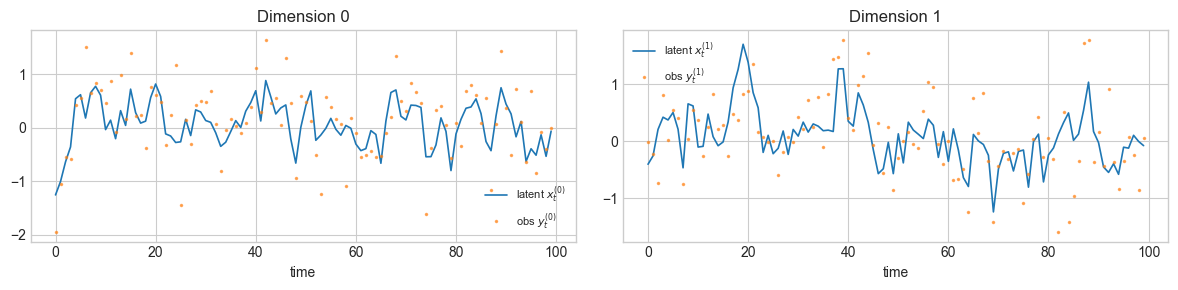

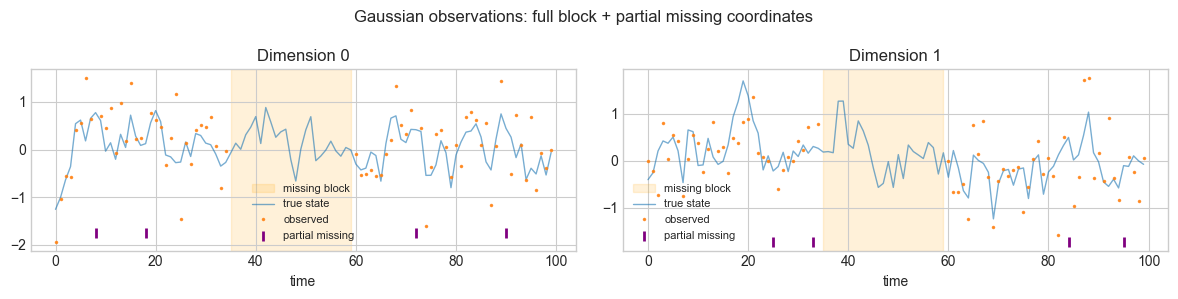

In [3]:
def ar1_model(obs_times=None, obs_values=None, predict_times=None):
    alpha = numpyro.sample("alpha", dist.Uniform(-0.7, 0.7))

    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim)),
        state_evolution=LinearGaussianStateEvolution(
            A=jnp.array([[alpha, 0.2], [-0.1, 0.8]]),
            cov=transition_cov,
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.eye(state_dim),
            R=mvn_obs_cov,
        ),
        control_dim=0,
    )
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


data_key, mcmc_key_sim, mcmc_key_smooth, pp_key = jr.split(jr.PRNGKey(0), 4)

n_mcmc_warmup = 150
n_mcmc_samples = 150

with DiscreteTimeSimulator():
    synthetic = Predictive(
        ar1_model,
        params={"alpha": jnp.array(true_alpha)},
        num_samples=1,
        exclude_deterministic=False,
    )(data_key, predict_times=obs_times)

states_clean = np.asarray(synthetic["f_states"].squeeze((0, 1)))
obs_clean = np.asarray(synthetic["f_observations"].squeeze((0, 1)))
t = np.asarray(obs_times)

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=False)
for d, ax in enumerate(axes):
    ax.plot(t, states_clean[:, d], color="C0", lw=1.2, label=f"latent $x^{{({d})}}_t$")
    ax.plot(t, obs_clean[:, d], ".", ms=3, color="C1", alpha=0.6, label=f"obs $y^{{({d})}}_t$")
    ax.set_xlabel("time")
    ax.set_title(f"Dimension {d}")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

obs_mvn_missing = np.asarray(apply_nan_mask(jnp.asarray(obs_clean), mask_full_plus_partial))
plot_missing_data(
    t,
    states_clean,
    obs_mvn_missing,
    partial_indices={0: partial_idx_dim0, 1: partial_idx_dim1},
    title="Gaussian observations: full block + partial missing coordinates",
)


In [4]:
def conditioned_simulator(obs_times=None, obs_values=None):
    with DiscreteTimeSimulator():
        ar1_model(obs_times=obs_times, obs_values=obs_values)


def conditioned_smoother(obs_times=None, obs_values=None):
    with Smoother(
        smoother_config=KFSmootherConfig(
            filter_source="cuthbert",
            record_smoothed_states_mean=True,
            record_smoothed_states_cov_diag=True,
        )
    ):
        ar1_model(obs_times=obs_times, obs_values=obs_values)


mcmc_simulator = MCMC(
    NUTS(conditioned_simulator),
    num_warmup=n_mcmc_warmup,
    num_samples=n_mcmc_samples,
    progress_bar=False,
)
mcmc_simulator.run(mcmc_key_sim, obs_times=obs_times, obs_values=jnp.asarray(obs_mvn_missing))

mcmc_smoother = MCMC(
    NUTS(conditioned_smoother),
    num_warmup=n_mcmc_warmup,
    num_samples=n_mcmc_samples,
    progress_bar=False,
)
mcmc_smoother.run(mcmc_key_smooth, obs_times=obs_times, obs_values=jnp.asarray(obs_mvn_missing))

posterior_alpha_simulator = np.asarray(mcmc_simulator.get_samples()["alpha"])
posterior_alpha_smoother = np.asarray(mcmc_smoother.get_samples()["alpha"])

simulator_state_samples = np.asarray(mcmc_simulator.get_samples()["f_states"])[:, 0]
simulator_summary = summarize_state_draws(simulator_state_samples)

with Smoother(
    smoother_config=KFSmootherConfig(
        filter_source="cuthbert",
        record_smoothed_states_mean=True,
        record_smoothed_states_cov_diag=True,
    )
):
    pp_smoother = Predictive(
        ar1_model,
        posterior_samples=mcmc_smoother.get_samples(),
        exclude_deterministic=False,
    )(jr.fold_in(pp_key, 1), obs_times=obs_times, obs_values=jnp.asarray(obs_mvn_missing))

smoothed_states = np.asarray(pp_smoother["f_smoothed_states_mean"])
smoothed_cov_diag = np.asarray(pp_smoother["f_smoothed_states_cov_diag"])
smoother_summary = summarize_gaussian_mixture(
    smoothed_states,
    smoothed_cov_diag,
    rng_key=jr.fold_in(pp_key, 11),
)


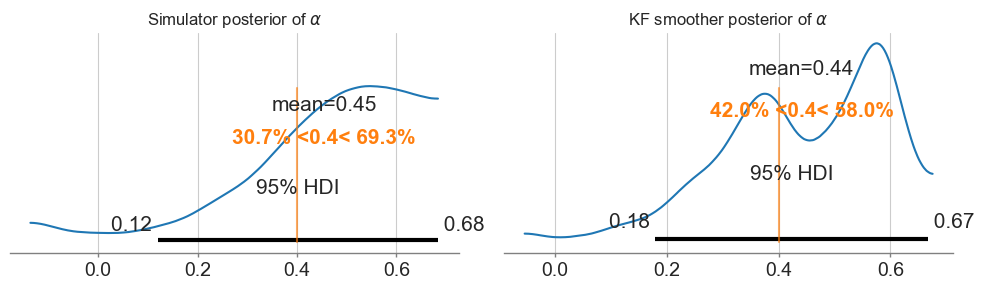

Simulator state RMSE: 0.3343762755393982
KF smoother state RMSE: 0.34210166335105896
Simulator missing-row RMSE: 0.395321786403656
KF smoother missing-row RMSE: 0.4110371768474579


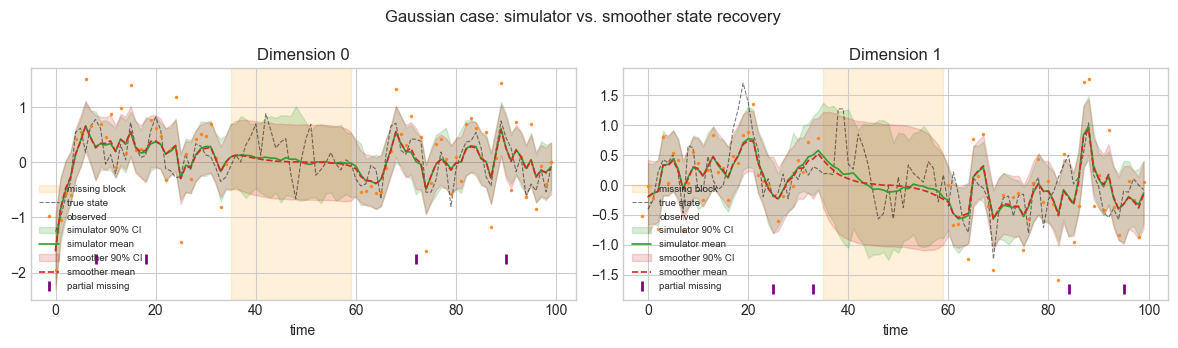

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
az.plot_posterior(posterior_alpha_simulator, hdi_prob=0.95, ref_val=true_alpha, ax=axes[0])
axes[0].set_title("Simulator posterior of $\\alpha$")
az.plot_posterior(posterior_alpha_smoother, hdi_prob=0.95, ref_val=true_alpha, ax=axes[1])
axes[1].set_title("KF smoother posterior of $\\alpha$")
plt.tight_layout()
plt.show()

missing_rows_mvn = ~mask_full_plus_partial.all(axis=1)
print("Simulator state RMSE:", rmse(simulator_summary["mean"], states_clean))
print("KF smoother state RMSE:", rmse(smoother_summary["mean"], states_clean))
print("Simulator missing-row RMSE:", rmse(simulator_summary["mean"][missing_rows_mvn], states_clean[missing_rows_mvn]))
print("KF smoother missing-row RMSE:", rmse(smoother_summary["mean"][missing_rows_mvn], states_clean[missing_rows_mvn]))

plot_state_recovery(
    t,
    states_clean,
    obs_mvn_missing,
    simulator_summary,
    label_a="simulator",
    color_a="C2",
    summary_b=smoother_summary,
    label_b="smoother",
    color_b="C3",
    partial_indices={0: partial_idx_dim0, 1: partial_idx_dim1},
    title="Gaussian case: simulator vs. smoother state recovery",
)


## 3. Example 2: independent asymmetric Laplace observations

Now keep the same latent AR(1)-style discrete-time setup, but switch the observation family to a coordinate-wise **asymmetric Laplace** model.

If we want to perform Filtering/Smoothing as before, we will need to use a Particle Filter/Smoother (due to these non-Gaussian observations); however, as noted in the previous tutorial, the PF/PS are currently not set up to automatically support missing data (it requires some extra by-hand work).

However, the `MCMC + Simulator()` strategy does all missingness (partial and full) + non-Gaussian observation models as long as the observation model is independent per observation dimension, which is the case here.

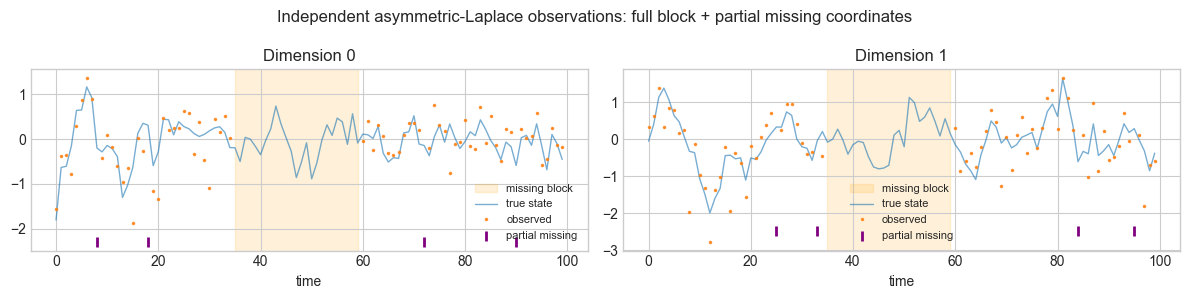

In [6]:
def asymmetric_laplace_model(obs_times=None, obs_values=None, predict_times=None):
    alpha = numpyro.sample("alpha", dist.Uniform(-0.7, 0.7))

    def observation_model(x, u, t):
        mean_shift = asym_laplace_scale * (1.0 / asym_laplace_k - asym_laplace_k)
        loc = x - mean_shift
        return dist.Independent(
            dist.AsymmetricLaplace(
                loc=loc,
                scale=asym_laplace_scale,
                asymmetry=asym_laplace_k,
            ),
            1,
        )

    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim)),
        state_evolution=LinearGaussianStateEvolution(
            A=jnp.array([[alpha, 0.2], [-0.1, 0.8]]),
            cov=transition_cov_non_gaussian,
        ),
        observation_model=observation_model,
        control_dim=0,
    )
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


with DiscreteTimeSimulator():
    asym_laplace_synth = Predictive(
        asymmetric_laplace_model,
        params={"alpha": jnp.array(true_alpha)},
        num_samples=1,
        exclude_deterministic=False,
    )(jr.PRNGKey(10), predict_times=obs_times)

asym_laplace_states_true = np.asarray(asym_laplace_synth["f_states"].squeeze((0, 1)))
asym_laplace_obs_clean = np.asarray(asym_laplace_synth["f_observations"].squeeze((0, 1))).astype(float)
asym_laplace_obs_missing = np.asarray(apply_nan_mask(jnp.asarray(asym_laplace_obs_clean), mask_full_plus_partial))

plot_missing_data(
    t,
    asym_laplace_states_true,
    asym_laplace_obs_missing,
    partial_indices={0: partial_idx_dim0, 1: partial_idx_dim1},
    title="Independent asymmetric-Laplace observations: full block + partial missing coordinates",
)


In [7]:
def conditioned_asymmetric_laplace_simulator(obs_times=None, obs_values=None):
    with DiscreteTimeSimulator():
        asymmetric_laplace_model(obs_times=obs_times, obs_values=obs_values)


mcmc_asym_laplace = MCMC(
    NUTS(conditioned_asymmetric_laplace_simulator),
    num_warmup=n_mcmc_warmup,
    num_samples=n_mcmc_samples,
    progress_bar=False,
)
mcmc_asym_laplace.run(jr.PRNGKey(11), obs_times=obs_times, obs_values=jnp.asarray(asym_laplace_obs_missing))

posterior_alpha_asym_laplace = np.asarray(mcmc_asym_laplace.get_samples()["alpha"])
asym_laplace_state_samples = np.asarray(mcmc_asym_laplace.get_samples()["f_states"])[:, 0]
asym_laplace_summary = summarize_state_draws(asym_laplace_state_samples)


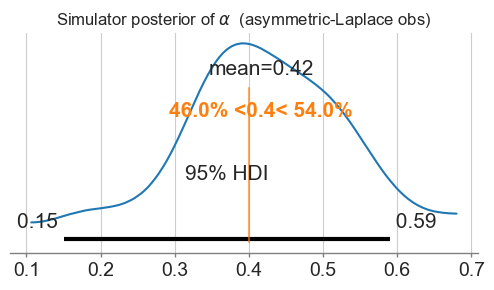

Asymmetric-Laplace simulator alpha: {'mean': 0.41657981276512146, 'p05': 0.20947781205177307, 'p95': 0.5842270255088806}
True alpha: 0.4
Asymmetric-Laplace state RMSE: 0.3254196345806122
Asymmetric-Laplace missing-row RMSE: 0.4429817199707031


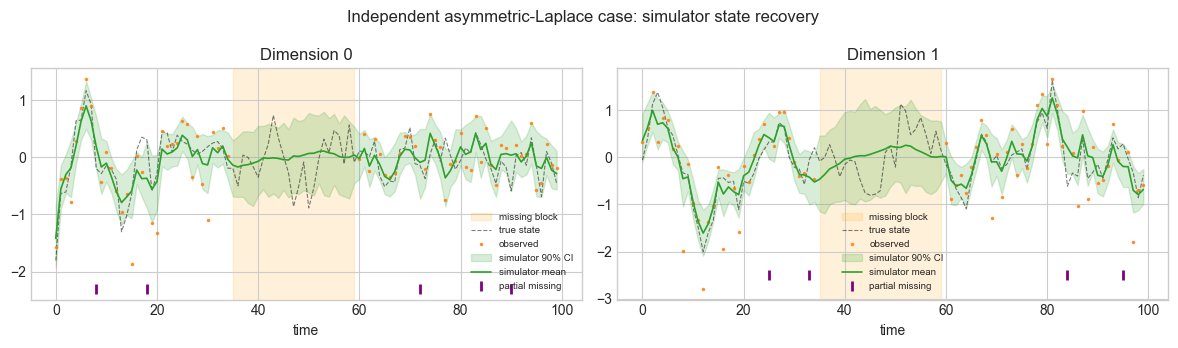

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
az.plot_posterior(posterior_alpha_asym_laplace, hdi_prob=0.95, ref_val=true_alpha, ax=ax)
ax.set_title("Simulator posterior of $\\alpha$  (asymmetric-Laplace obs)")
plt.tight_layout()
plt.show()

print("Asymmetric-Laplace simulator alpha:", summarize_1d(posterior_alpha_asym_laplace))
print("True alpha:", true_alpha)
print("Asymmetric-Laplace state RMSE:", rmse(asym_laplace_summary["mean"], asym_laplace_states_true))
print(
    "Asymmetric-Laplace missing-row RMSE:",
    rmse(
        asym_laplace_summary["mean"][~mask_full_plus_partial.all(axis=1)],
        asym_laplace_states_true[~mask_full_plus_partial.all(axis=1)],
    ),
)

plot_state_recovery(
    t,
    asym_laplace_states_true,
    asym_laplace_obs_missing,
    asym_laplace_summary,
    label_a="simulator",
    color_a="C2",
    partial_indices={0: partial_idx_dim0, 1: partial_idx_dim1},
    title="Independent asymmetric-Laplace case: simulator state recovery",
)


## 4. Example 3: a correlated multivariate Student $t$

Finally, consider a correlated non-Gaussian observation family: a multivariate Student $t$.

For a generic correlated observation model, partial missingness is no longer something we can treat with a one-line generic rule. The simulator would need model-specific code for

$$
p(y_{k, O_k} \mid x_k, \alpha),
$$

and that formula depends on the observation family.

That is why this case is **not currently supported for partial missingness**.

Still, **full-row missingness is fine**. When the whole row is missing (e.g. all sensors dropped out), the observation factor at that index simply disappears, regardless of how complicated the observation model is.

So here we use the **full-row-only** mask and again compare the simulator the **truth**.


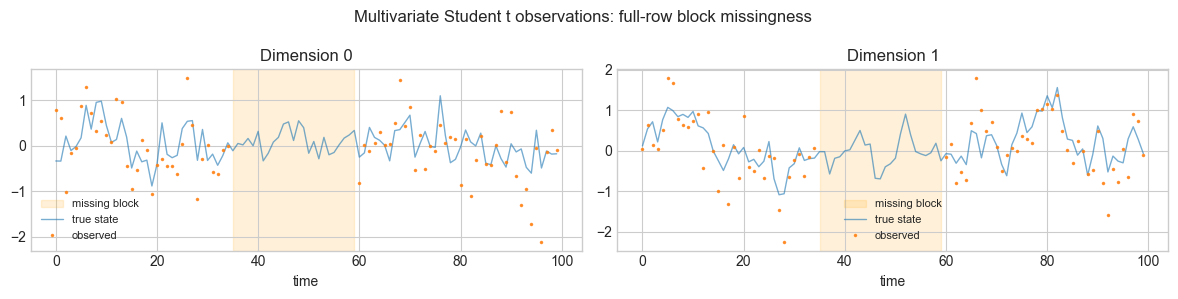

In [9]:
def student_t_model(obs_times=None, obs_values=None, predict_times=None):
    alpha = numpyro.sample("alpha", dist.Uniform(-0.7, 0.7))

    dynamics = DynamicalModel(
        initial_condition=dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim)),
        state_evolution=LinearGaussianStateEvolution(
            A=jnp.array([[alpha, 0.2], [-0.1, 0.8]]),
            cov=transition_cov_non_gaussian,
        ),
        observation_model=lambda x, u, t: dist.MultivariateStudentT(
            df=student_df,
            loc=x,
            scale_tril=student_scale_tril,
        ),
        control_dim=0,
    )
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


with DiscreteTimeSimulator():
    student_synth = Predictive(
        student_t_model,
        params={"alpha": jnp.array(true_alpha)},
        num_samples=1,
        exclude_deterministic=False,
    )(jr.PRNGKey(20), predict_times=obs_times)

student_states_true = np.asarray(student_synth["f_states"].squeeze((0, 1)))
student_obs_clean = np.asarray(student_synth["f_observations"].squeeze((0, 1)))
student_obs_missing = np.asarray(apply_nan_mask(jnp.asarray(student_obs_clean), mask_full_only))

plot_missing_data(
    t,
    student_states_true,
    student_obs_missing,
    title="Multivariate Student t observations: full-row block missingness",
)


In [10]:
def conditioned_student_t_simulator(obs_times=None, obs_values=None):
    with DiscreteTimeSimulator():
        student_t_model(obs_times=obs_times, obs_values=obs_values)


mcmc_student = MCMC(
    NUTS(conditioned_student_t_simulator),
    num_warmup=n_mcmc_warmup,
    num_samples=n_mcmc_samples,
    progress_bar=False,
)
mcmc_student.run(jr.PRNGKey(21), obs_times=obs_times, obs_values=jnp.asarray(student_obs_missing))

posterior_alpha_student = np.asarray(mcmc_student.get_samples()["alpha"])
student_state_samples = np.asarray(mcmc_student.get_samples()["f_states"])[:, 0]
student_summary = summarize_state_draws(student_state_samples)
missing_rows_student = ~mask_full_only.all(axis=1)


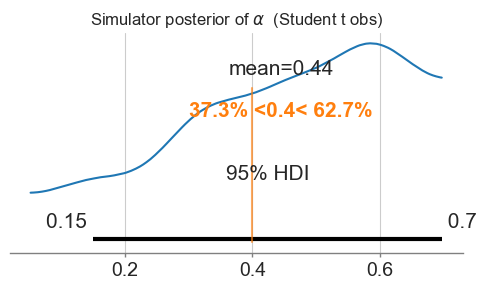

Student t simulator alpha: {'mean': 0.44460269808769226, 'p05': 0.14976708590984344, 'p95': 0.6652595400810242}
True alpha: 0.4
Student t state RMSE: 0.32692649960517883
Student t missing-row RMSE: 0.3392679691314697


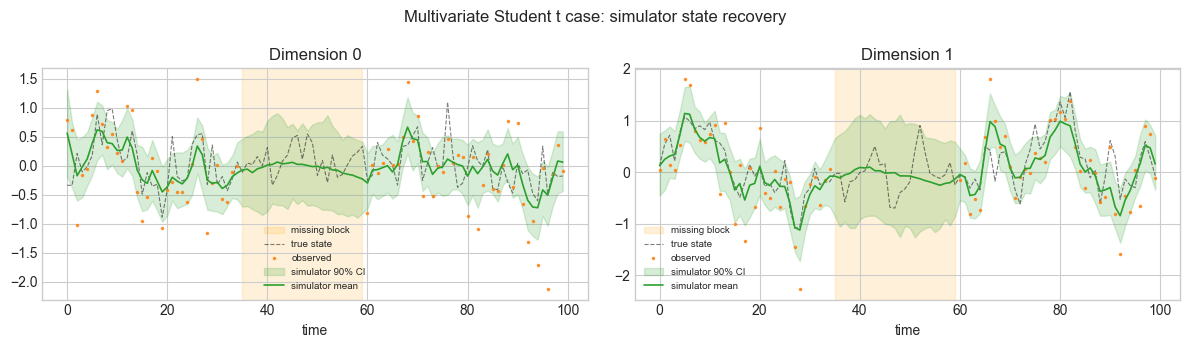

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
az.plot_posterior(posterior_alpha_student, hdi_prob=0.95, ref_val=true_alpha, ax=ax)
ax.set_title("Simulator posterior of $\\alpha$  (Student t obs)")
plt.tight_layout()
plt.show()

print("Student t simulator alpha:", summarize_1d(posterior_alpha_student))
print("True alpha:", true_alpha)
print("Student t state RMSE:", rmse(student_summary["mean"], student_states_true))
print("Student t missing-row RMSE:", rmse(student_summary["mean"][missing_rows_student], student_states_true[missing_rows_student]))

plot_state_recovery(
    t,
    student_states_true,
    student_obs_missing,
    student_summary,
    label_a="simulator",
    color_a="C2",
    title="Multivariate Student t case: simulator state recovery",
)


## Summary

The clean simulator-side interpretation is:

- `obs_values[k]` always belongs to latent index $k$;
- a **fully missing** row means: keep $x_k$, but add **no observation factor** at that index;
- a **partially missing** row means: keep $x_k$ and score only the observed part of $y_k$.

That immediately implies the key scope split:

- **full-row missingness** works for **all** observation models under the simulator;
- **partial missingness** needs exploitable structure.

In this tutorial that structure was:

- **multivariate Gaussian**: restrict to the observed subvector and covariance submatrix;
- **independent asymmetric-Laplace observations**: sum only the observed-coordinate log-probabilities.

For a correlated non-Gaussian observation model, like a multivariate Student $t$, partial missingness would require model-specific marginalization code, so we currently fall back to the simpler supported scope: **full-row missingness only**.

Finally, the comparison story (w.r.t. Smoothers) depends on the observation family:

- for the **Gaussian** case, the simulator and the Kalman smoother can be compared directly;
- for the **non-Gaussian** missing-data cases shown here, the simulator is currently the primary automagic path; future work can make the Particle Smoothers apply more automatically.
